# Day 8: Fashion MNIST Image Classification with CNN

In [1]:
#Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

In [2]:
# Load the Fashion MNIST dataset from TensorFlow
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

4422102/4422102 [==============================] - 1s 0us/step


In [3]:
# Display the dataset shape
print(f"Training Data Shape: {X_train.shape}")
print(f"Testing Data Shape: {X_test.shape}")

Training Data Shape: (60000, 28, 28)
Testing Data Shape: (10000, 28, 28)


In [4]:
# Normalize pixel values to the range [0, 1]
X_train = X_train / 255.0
X_test = X_test / 255.0

In [5]:
# Reshape data to include a channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)


In [6]:
# One-hot encode the target labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [7]:
#Build the CNN Model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    Dropout(0.2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

In [8]:
# Display the model architecture
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 26, 26, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2  (None, 13, 13, 32)        0         
 D)                                                              
                                                                 
 dropout (Dropout)           (None, 13, 13, 32)        0         
                                                                 
 conv2d_1 (Conv2D)           (None, 11, 11, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 5, 5, 64)          0         
 g2D)                                                            
                                                                 
 dropout_1 (Dropout)         (None, 5, 5, 64)          0

In [9]:
#Compile the Model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
# Train the model
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=64
)

Epoch 1/10
750/750 [==============================] - 29s 34ms/step - loss: 0.6209 - accuracy: 0.7739 - val_loss: 0.4014 - val_accuracy: 0.8570
Epoch 2/10
750/750 [==============================] - 24s 32ms/step - loss: 0.4128 - accuracy: 0.8514 - val_loss: 0.3437 - val_accuracy: 0.8752
Epoch 3/10
750/750 [==============================] - 25s 33ms/step - loss: 0.3591 - accuracy: 0.8689 - val_loss: 0.3109 - val_accuracy: 0.8846
Epoch 4/10
750/750 [==============================] - 23s 31ms/step - loss: 0.3251 - accuracy: 0.8806 - val_loss: 0.2879 - val_accuracy: 0.8963
Epoch 5/10
750/750 [==============================] - 25s 33ms/step - loss: 0.3010 - accuracy: 0.8887 - val_loss: 0.2821 - val_accuracy: 0.8946
Epoch 6/10
750/750 [==============================] - 25s 33ms/step - loss: 0.2873 - accuracy: 0.8951 - val_loss: 0.2637 - val_accuracy: 0.9040
Epoch 7/10
750/750 [==============================] - 25s 33ms/step - loss: 0.2721 - accuracy: 0.9003 - val_loss: 0.2671 - val_accuracy:

In [11]:
# Evaluate on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy:.2f}")

313/313 [==============================] - 4s 12ms/step - loss: 0.2444 - accuracy: 0.9098
Test Accuracy: 0.91


In [12]:
# Plot accuracy and loss over epochs
plt.figure(figsize=(12, 5))

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

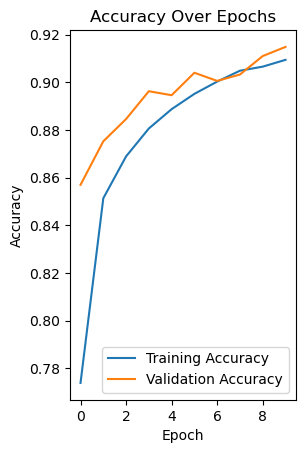

In [13]:
# Plot training and validation accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

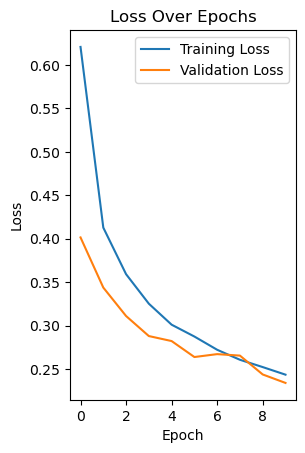

In [14]:
# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [15]:
# Predict on test data
predictions = model.predict(X_test)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(y_test, axis=1)

313/313 [==============================] - 4s 11ms/step


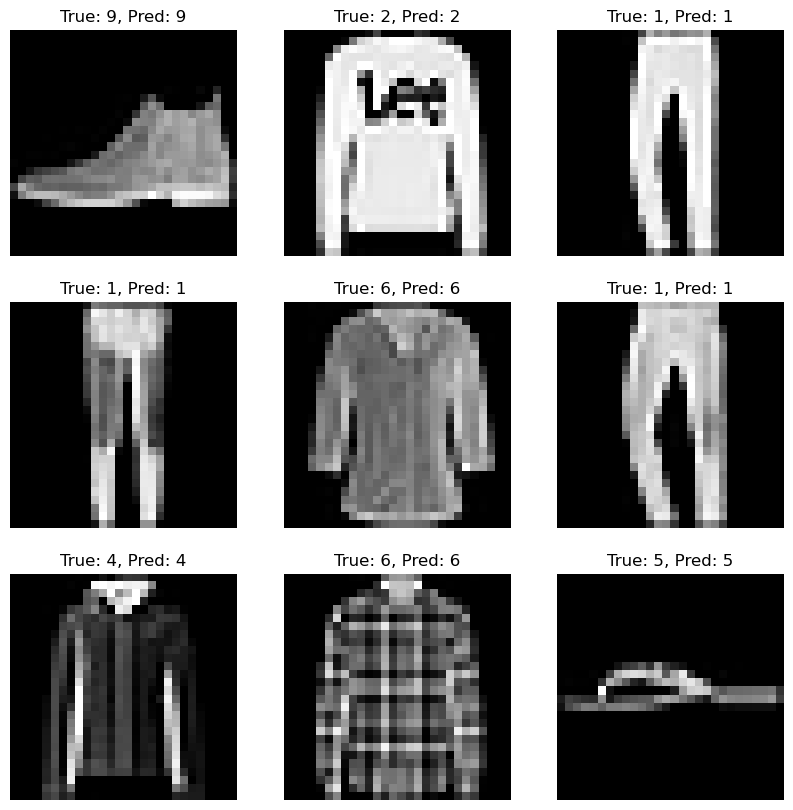

In [16]:
# Plot some test images with predictions
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    plt.title(f"True: {true_classes[i]}, Pred: {predicted_classes[i]}")
    plt.axis('off')
plt.show()